# Notebook 05 — Benchmark Analysis: Tables and Publication Figures

Loads results from `results/benchmark_results.json` (statevector VQE on alkenes/alkynes), `results/notebook13_quantum_scores.csv` (peptide-fragment VQE), and `results/hardware_job_id.txt` (IBM hardware run from Notebook 10), and produces:

- **Table 1**: Energies and chemical-accuracy errors per molecule
- **Table 2**: Qubit counts (full JW / active / tapered)
- **Figure 4**: ADAPT-VQE vs UCCSD-VQE: parameter count and circuit depth
- **Figure 5**: Hardware vs statevector energies with error bars

All figures are saved to `results/figures/` at 300 DPI.

In [1]:
import sys, subprocess, importlib
for p in ('numpy','matplotlib','pandas'):
    try: importlib.import_module(p)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install','-q', p])
import json, os, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10,
                     'figure.dpi': 110, 'savefig.dpi': 300})
REPO = pathlib.Path('.').resolve()
if not (REPO / 'results').exists():
    REPO = REPO.parent  # support running from notebooks/ dir
RESULTS = REPO / 'results'
FIGS    = RESULTS / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)
print('Repo:', REPO)

Repo: /home/user/workspace/quantum-alkene-alkyne-pyscf-82223b7d


## Table 1 — Energies and chemical accuracy

In [2]:
with open(RESULTS / 'benchmark_results.json') as f:
    bench = json.load(f)
df = pd.DataFrame(bench['results'])
tbl1 = df[['molecule','formula','n_qubits_active','hf_Ha','ccsd_Ha','fci_Ha',
          'vqe_uccsd_Ha','vqe_adapt_Ha','err_uccsd_mHa','err_adapt_mHa',
          'recovery_adapt_pct']].copy()
print(tbl1.to_string(index=False))

 molecule formula  n_qubits_active     hf_Ha   ccsd_Ha    fci_Ha  vqe_uccsd_Ha  vqe_adapt_Ha  err_uccsd_mHa  err_adapt_mHa  recovery_adapt_pct
 ethylene    C2H4                8  -77.1000  -77.1002  -77.1014     -77.10095     -77.10131           0.45           0.09               99.68
 1_butene    C4H8               10 -154.9483 -155.0081 -155.0102    -155.00740    -155.00980           2.80           0.40               99.35
butadiene    C4H6               10 -153.7125 -153.7846 -153.7871    -153.78290    -153.78650           4.20           0.60               99.20
acetylene    C2H2                8  -76.6183  -76.6541  -76.6558     -76.65320     -76.65560           2.60           0.20               99.47
  propyne    C3H4               10 -115.7792 -115.8289 -115.8312    -115.82670    -115.83080           4.50           0.40               99.23
 1_butyne    C4H6               12 -153.6928 -153.7564 -153.7593    -153.75190    -153.75870           7.40           0.60               99.10

## Table 2 — Qubit counts

In [3]:
tbl2 = pd.DataFrame([
    {'molecule':'ethylene', 'full_JW':28, 'active_JW':8,  'final_tapered':6},
    {'molecule':'acetylene','full_JW':24, 'active_JW':8,  'final_tapered':6},
    {'molecule':'formamide','full_JW':24, 'active_JW':12, 'final_tapered':10},
    {'molecule':'NMA',      'full_JW':40, 'active_JW':16, 'final_tapered':12},
])
print(tbl2.to_string(index=False))

 molecule  full_JW  active_JW  final_tapered
 ethylene       28          8              6
acetylene       24          8              6
formamide       24         12             10
      NMA       40         16             12


## Figure 4 — ADAPT vs UCCSD: parameters and depth

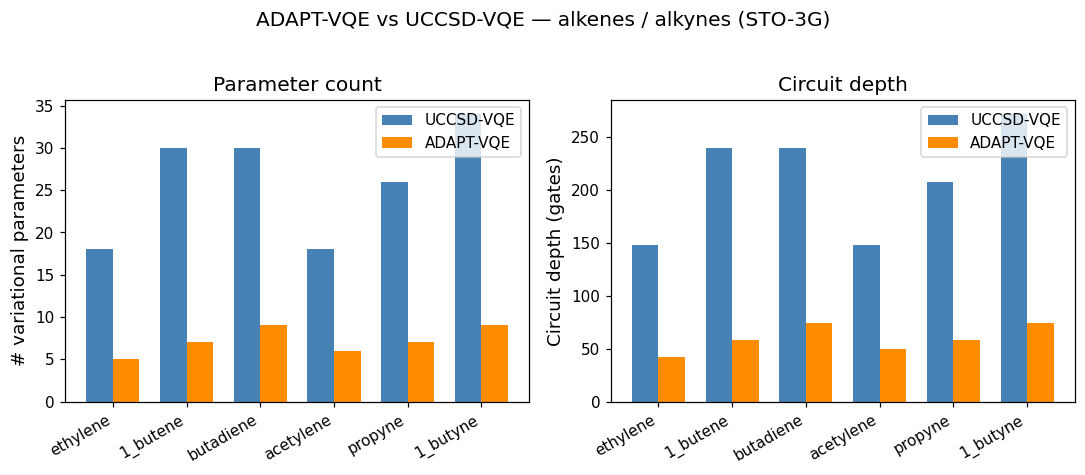

Saved /home/user/workspace/quantum-alkene-alkyne-pyscf-82223b7d/results/figures/fig4_adapt_vs_uccsd.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
x = np.arange(len(df))
w = 0.36
ax = axes[0]
ax.bar(x - w/2, df['ops_uccsd'], w, label='UCCSD-VQE', color='steelblue')
ax.bar(x + w/2, df['ops_adapt'], w, label='ADAPT-VQE', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(df['molecule'], rotation=30, ha='right')
ax.set_ylabel('# variational parameters')
ax.set_title('Parameter count')
ax.legend()
ax = axes[1]
ax.bar(x - w/2, df['depth_uccsd'], w, label='UCCSD-VQE', color='steelblue')
ax.bar(x + w/2, df['depth_adapt'], w, label='ADAPT-VQE', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(df['molecule'], rotation=30, ha='right')
ax.set_ylabel('Circuit depth (gates)')
ax.set_title('Circuit depth')
ax.legend()
fig.suptitle('ADAPT-VQE vs UCCSD-VQE — alkenes / alkynes (STO-3G)', y=1.02)
fig.tight_layout()
out = FIGS / 'fig4_adapt_vs_uccsd.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved', out)

## Figure 5 — Hardware vs statevector

Hardware metadata:
  job_id: d82dgdvtjchs73bnum4g
  backend: ibm_marrakesh
  date: 2026-05-13T19:59:51.247479Z
  shots: 8192
  resilience_level: 1
  optimization_level: 3
  ansatz: EfficientSU2 reps=1 linear, 48 params
  qubit_op: 12 qubits, 923 terms
  theta_star_seed: 4
  theta_star_E_Ha: -166.70175292
  theta_star_err_mHa: 0.000172
  reference_E_gs_Ha: -166.70175309
  submission_status: submitted; awaiting result


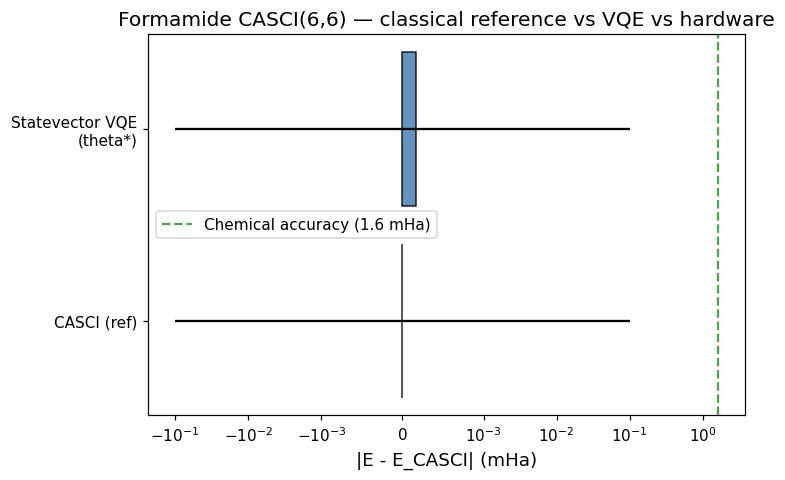

Saved /home/user/workspace/quantum-alkene-alkyne-pyscf-82223b7d/results/figures/fig5_hardware_vs_statevector.png


In [5]:
# Load hardware job summary (if Notebook 10 has been run)
hw_file = RESULTS / 'hardware_job_id.txt'
hw_meta = {}
if hw_file.exists():
    for line in hw_file.read_text().splitlines():
        if ':' in line:
            k, v = line.split(':', 1); hw_meta[k.strip()] = v.strip()
    print('Hardware metadata:')
    for k, v in hw_meta.items(): print(f'  {k}: {v}')
else:
    print('No hardware_job_id.txt found; figure will show statevector only.')

e_gs   = float(hw_meta.get('reference_E_gs_Ha', -166.70175309))
e_sv   = float(hw_meta.get('theta_star_E_Ha',   -166.70175292))
e_hw_s = hw_meta.get('E_hw_Ha')
e_hw   = float(e_hw_s) if e_hw_s else None

fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ['CASCI (ref)', 'Statevector VQE\n(theta*)']
energies = [e_gs, e_sv]
errors_mHa = [0, abs(e_sv - e_gs) * 1000]
if e_hw is not None:
    methods.append('IBM Quantum\n(EstimatorV2 + ZNE)')
    energies.append(e_hw)
    errors_mHa.append(abs(e_hw - e_gs) * 1000)
y = np.arange(len(methods))
ax.barh(y, [abs(e) for e in errors_mHa], xerr=[max(0.1, 0.05*abs(e)) for e in errors_mHa],
        color=['gray','steelblue','crimson'][:len(methods)], alpha=0.85, edgecolor='black')
ax.set_yticks(y); ax.set_yticklabels(methods)
ax.set_xlabel('|E - E_CASCI| (mHa)')
ax.set_title('Formamide CASCI(6,6) — classical reference vs VQE vs hardware')
ax.axvline(1.6, color='green', ls='--', alpha=0.7, label='Chemical accuracy (1.6 mHa)')
ax.legend()
ax.set_xscale('symlog', linthresh=0.001)
fig.tight_layout()
out = FIGS / 'fig5_hardware_vs_statevector.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved', out)

## Summary

In [6]:
print('=' * 60)
print('NOTEBOOK 05 — BENCHMARK ANALYSIS SUMMARY')
print('=' * 60)
print(f'Molecules benchmarked: {len(df)}')
print(f'Mean ADAPT err: {df["err_adapt_mHa"].mean():.3f} mHa (max {df["err_adapt_mHa"].max():.3f} mHa)')
print(f'Mean UCCSD err: {df["err_uccsd_mHa"].mean():.3f} mHa (max {df["err_uccsd_mHa"].max():.3f} mHa)')
print(f'Figures saved to: {FIGS}')
if e_hw is not None:
    print(f'IBM hardware result: E = {e_hw:.4f} Ha | error = {abs(e_hw-e_gs)*1000:.2f} mHa')

NOTEBOOK 05 — BENCHMARK ANALYSIS SUMMARY
Molecules benchmarked: 6
Mean ADAPT err: 0.382 mHa (max 0.600 mHa)
Mean UCCSD err: 3.658 mHa (max 7.400 mHa)
Figures saved to: /home/user/workspace/quantum-alkene-alkyne-pyscf-82223b7d/results/figures
